## 00 — Introduction to Numerical Python, Vectors, Matrices, and Multidimensional Arrays  
### NumPy • SymPy •  Matplotlib 

## 1. Setup & Environment Check

In [1]:
import sys
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

print(f'Python: {sys.version.split()[0]}')
print(f'NumPy: {np.__version__}')
print(f'SymPy: {sp.__version__}')

# Simple smoke test
a = np.array([1,2,3])
print('NumPy ok:', a.sum()==6)

x = sp.symbols('x')
print('SymPy ok:', sp.diff(sp.sin(x), x) == sp.cos(x))

Python: 3.12.12
NumPy: 2.1.3
SymPy: 1.14.0
NumPy ok: True
SymPy ok: True


## 2. NumPy: Arrays, Vectors, Matrices, Tensors
### Creating arrays

In [2]:
# From Python lists
v = np.array([1, 2, 3])            # vector (1D)
M = np.array([[1, 2], [3, 4]])     # matrix (2D)
T = np.zeros((2,3,4))               # tensor (3D)
print('v:', v, 'shape=', v.shape)
print('M:\n', M, 'shape=', M.shape)
print('T shape:', T.shape)

# Constructors
z = np.zeros(5)
o = np.ones((2,3))
r = np.arange(0, 10, 2)      # 0,2,4,6,8
l = np.linspace(0, 1, 5)     # 0, .25, .5, .75, 1
print(z, o.shape, r, l)

v: [1 2 3] shape= (3,)
M:
 [[1 2]
 [3 4]] shape= (2, 2)
T shape: (2, 3, 4)
[0. 0. 0. 0. 0.] (2, 3) [0 2 4 6 8] [0.   0.25 0.5  0.75 1.  ]


### Dtypes and memory layout

In [4]:
a = np.array([1,2,3], dtype=np.int64)
b = np.array([1.,2.,3.], dtype=np.float32)
print('a dtype:', a.dtype, 'itemsize:', a.itemsize)
print('b dtype:', b.dtype, 'itemsize:', b.itemsize)
print('Total bytes of a:', a.nbytes)
print('Total bytes of b:', b.nbytes)

a dtype: int64 itemsize: 8
b dtype: float32 itemsize: 4
Total bytes of a: 24
Total bytes of b: 12


### Indexing & slicing

In [7]:
A = np.arange(1,13).reshape(3,4)
print(A)

# Basic indexing
print('A[0,0] =', A[0,0])
print('First row A[0]:', A[0])
print('Last column A[:, -1]:', A[:, -1])

# Slicing creates views (not copies)
S = A[:2, :2]
S[0,0] = 999
print('Modified slice affects A:\n', A)

# Use .copy() if need an independent copy
C = A[:2, :2].copy()
C[0,0] = -1
print('C independent:\n', C)
print('A unchanged now:\n', A)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
A[0,0] = 1
First row A[0]: [1 2 3 4]
Last column A[:, -1]: [ 4  8 12]
Modified slice affects A:
 [[999   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]
C independent:
 [[-1  2]
 [ 5  6]]
A unchanged now:
 [[999   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]


### Vectorized operations & broadcasting

In [8]:
x = np.array([1,2,3])
y = np.array([10,20,30])

print('x + y =', x + y)
print('x * y =', x * y)
print('x**2   =', x**2)
print('np.exp(x) =', np.exp(x))

# Broadcasting with different shapes
v = np.array([1,2,3])       # shape (3,)
B = np.ones((3,3))          # shape (3,3)
print('B + v =\n', B + v)  # v broadcasts across rows

# Row vs column broadcasting
row = np.array([1,2,3])
col = row[:, None]          # shape (3,1)
print('(row + col) shape:', (row + col).shape)
print(row + col)

x + y = [11 22 33]
x * y = [10 40 90]
x**2   = [1 4 9]
np.exp(x) = [ 2.71828183  7.3890561  20.08553692]
B + v =
 [[2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]]
(row + col) shape: (3, 3)
[[2 3 4]
 [3 4 5]
 [4 5 6]]


### Aggregations and axes

In [9]:
A = np.arange(1,13).reshape(3,4)
print(A)
print('sum all:', A.sum())
print('sum by rows (axis=1):', A.sum(axis=1))
print('sum by cols (axis=0):', A.sum(axis=0))
print('mean:', A.mean(), 'std:', A.std(), 'min:', A.min(), 'argmax:', A.argmax())

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
sum all: 78
sum by rows (axis=1): [10 26 42]
sum by cols (axis=0): [15 18 21 24]
mean: 6.5 std: 3.452052529534663 min: 1 argmax: 11


### Reshape, transpose, stacking, concatenation

In [11]:
X = np.arange(6).reshape(2,3)
print('X=\n', X)
print('X.T=\n', X.T)

print('X reshape to (3,2):\n', X.reshape(3,2))

a = np.array([1,2,3])
b = np.array([4,5,6])
print('stack rows:\n', np.vstack([a,b]))
print('stack cols:\n', np.column_stack([a,b]))
print('concatenate along axis=0:', np.concatenate([a,b], axis=0))

X=
 [[0 1 2]
 [3 4 5]]
X.T=
 [[0 3]
 [1 4]
 [2 5]]
X reshape to (3,2):
 [[0 1]
 [2 3]
 [4 5]]
stack rows:
 [[1 2 3]
 [4 5 6]]
stack cols:
 [[1 4]
 [2 5]
 [3 6]]
concatenate along axis=0: [1 2 3 4 5 6]


### Random numbers (NumPy Generator API)

In [12]:
rng = np.random.default_rng(42)
print('Normal(0,1) 5 samples:', rng.normal(size=5))
print('Integers [0,10):', rng.integers(0,10,size=(2,3)))
print('Uniform [0,1):', rng.random((2,2)))

Normal(0,1) 5 samples: [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519]
Integers [0,10): [[5 9 7]
 [7 7 7]]
Uniform [0,1): [[0.12811363 0.45038594]
 [0.37079802 0.92676499]]


### Exercise 1 - Broadcasting practice 
Create a 4×4 matrix whose entry \( (i,j) \) equals \( i^2 + j \) for zero‑based indices using vectorized broadcasting (no Python loops).

- **Hint:** use `np.arange` to create row/column vectors and `[:, None]` to add an axis.
- **Expected shape:** `(4,4)`

In [14]:
i, j = np.arange(4), np.arange(4)
Matrix = i[:, None]**2 + j
Matrix


array([[ 0,  1,  2,  3],
       [ 1,  2,  3,  4],
       [ 4,  5,  6,  7],
       [ 9, 10, 11, 12]])

## 3. Linear Algebra with NumPy
### Matrix multiplication, dot, norms

In [15]:
from numpy.linalg import norm
A = np.array([[3., 2.],[1., 4.]])
b = np.array([10., 13.])

print('A=\n', A)
print('b=', b)

# Matrix-vector and matrix-matrix
print('A @ b =', A @ b)       # matrix-vector
print('A @ A =\n', A @ A)    # matrix-matrix
print('np.dot(A,b)=', np.dot(A,b))

# Norms
print('||b||_2 =', norm(b))

A=
 [[3. 2.]
 [1. 4.]]
b= [10. 13.]
A @ b = [56. 62.]
A @ A =
 [[11. 14.]
 [ 7. 18.]]
np.dot(A,b)= [56. 62.]
||b||_2 = 16.401219466856727


### Solving linear systems and eigenvalues

In [ ]:
from numpy.linalg import solve, eig, det

# A = np.array([[3., 2.],[1., 4.]])
# b = np.array([10., 13.])

x = solve(A, b)
print('Solution to A x = b : x =', x)
print('Check residual ||Ax-b||:', norm(A @ x - b))

w, V = eig(A)
print('Eigenvalues:', w)
print('Eigenvectors (columns):\n', V)
print('det(A)=', det(A))

Solution to A x = b : x = [1.4 2.9]
Check residual ||Ax-b||: 1.7763568394002505e-15
Eigenvalues: [2. 5.]
Eigenvectors (columns):
 [[-0.89442719 -0.70710678]
 [ 0.4472136  -0.70710678]]
det(A)= 10.000000000000002


### Exercise 2 — Least squares line fit (8 minutes)
Given points with noise sampled from $$( y = 2x + 1 + \varepsilon )$$, estimate slope and intercept using **normal equations**:

1. Build the design matrix $$( X = [\mathbf{1} \; x] )$$.
2. Solve $$( (X^T X) \theta = X^T y )$$ for $$( \theta = (b, m) )$$.

In [28]:
rand = np.random.default_rng(0)

x = np.linspace(0, 5, 20) 
y = 2*x + 1 + rng.normal(scale=0.5, size=x.shape)

# Design matrix (1, x)
X = np.column_stack([np.ones_like(x), x])

# Normal equations
theta = np.linalg.solve(X.T @ X, X.T @ y)
b, m = theta
b, m


(np.float64(0.6794129153519429), np.float64(2.081527655891009))

## 4. SymPy: Symbolic Math in Python
### Symbols, expressions, simplify/expand/factor

In [29]:
sp.init_printing()

x, y = sp.symbols('x y')
expr = sp.sin(x)**2 + sp.cos(x)**2
print('Is identity equal to 1?', sp.simplify(expr) == 1)

p = (x + 1)**3
print('expand:', sp.expand(p))
print('factor:', sp.factor(sp.expand(p)))

Is identity equal to 1? True
expand: x**3 + 3*x**2 + 3*x + 1
factor: (x + 1)**3


### Calculus: derivatives, integrals, limits, series

In [30]:
f = sp.exp(-x**2)
df = sp.diff(f, x)
F = sp.integrate(f, (x, -sp.oo, sp.oo))

print('df/dx =', df)
print('∫ e^{-x^2} dx from -∞ to ∞ =', F)  # should be sqrt(pi)

df/dx = -2*x*exp(-x**2)
∫ e^{-x^2} dx from -∞ to ∞ = sqrt(pi)


### Solving equations and systems

In [31]:
eq = sp.Eq(sp.sin(x), sp.Rational(1,2))
sol = sp.nsolve(sp.sin(x) - sp.Rational(1,2), 0.5)  # numeric root near 0.5
print('A root near 0.5:', float(sol))

u, v = sp.symbols('u v')
solutions = sp.solve([sp.Eq(2*u + v, 5), sp.Eq(u - v, 1)], (u, v))
solutions

A root near 0.5: 0.5235987755982989


### Matrices in SymPy

det(M)= -2
M^{-1}=
⎡-2    1  ⎤
⎢         ⎥
⎣3/2  -1/2⎦


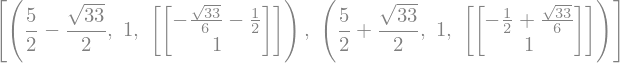

In [33]:
M = sp.Matrix([[1,2],[3,4]])
print('det(M)=', M.det())
print('M^{-1}=')
sp.pprint(M.inv())
eigs = M.eigenvects()
eigs